Fintech Transaction Data Analysis


In [ ]:
##Objective: Clean, analyze, and visualize transaction data to provide actionable business insights
##for growth and fraud mitigation.



In [1]:
##Step 1: Data Loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (Assuming the file is named fintech_dataset.csv)
df = pd.read_csv('/content/fintech_dataset-1.csv')

# Display first few rows
print(df.head())


   transaction_id  user_id  transaction_amount transaction_type  \
0               1     1102           465043.41          payment   
1               2     1435            35672.86          airtime   
2               3     1860           104854.90          airtime   
3               4     1270           335736.19             bill   
4               5     1106           179644.07         transfer   

  payment_channel transaction_status         region device_type  fraud_flag  \
0          wallet            success          Lagos         ios           0   
1   bank_transfer            success  Port Harcourt     android           0   
2            card            success          Lagos         web           0   
3   bank_transfer            success         Ibadan         web           0   
4          wallet            success  Port Harcourt         ios           0   

             timestamp  
0  2025-01-01 00:00:00  
1  2025-01-01 01:00:00  
2  2025-01-01 02:00:00  
3  2025-01-01 03:00:00

In [2]:
### Check structure
df.info()
print(f"Shape: {df.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_id      500 non-null    int64  
 1   user_id             500 non-null    int64  
 2   transaction_amount  500 non-null    float64
 3   transaction_type    500 non-null    object 
 4   payment_channel     500 non-null    object 
 5   transaction_status  500 non-null    object 
 6   region              500 non-null    object 
 7   device_type         500 non-null    object 
 8   fraud_flag          500 non-null    int64  
 9   timestamp           500 non-null    object 
dtypes: float64(1), int64(3), object(6)
memory usage: 39.2+ KB
Shape: (500, 10)


In [5]:
##Step 2: Data Cleaning

# Check for missing values
missing_vals = df.isnull().sum()

# Remove duplicates
df = df.drop_duplicates()

# Convert timestamp to datetime objects
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Handle outliers (e.g., extremely high amounts compared to Average Transaction Value)
# From sources, amounts vary significantly from 1,796 to 497,967 [2, 3].

In [10]:
##Step 3: Exploratory Data Analysis (EDA)

# Total transactions
total_tx = len(df)

# Success vs Failed vs Pending
status_counts = df['transaction_status'].value_counts()

# Transactions by type
type_counts = df['transaction_type'].value_counts()

# Fraudulent vs non-fraudulent
fraud_counts = df['fraud_flag'].value_counts()

##Step 4: KPI Metrics


In [ ]:
##These metrics reflect the health of the fintech platform.
#Total Revenue (Successful Transactions): Sum of transaction_amount where transaction_status is 'success'

#Transaction Success Rate: Percentage of 'success' vs total transactions

#Fraud Rate: Percentage of transactions where fraud_flag is 1

#Average Transaction Value (ATV): Mean of the transaction_amount column

#Top Performing Region: Region with the highest total success value (often Lagos or Abuja in this set)


#Step 5: Data Visualization


<Axes: xlabel='transaction_type', ylabel='count'>

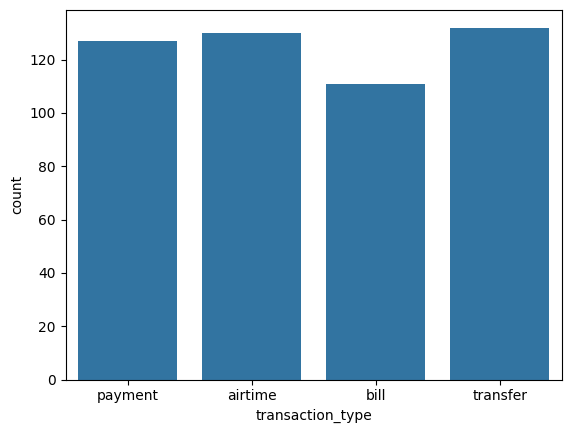

In [7]:
## These charts provide a visual representation of the data trends.
# Bar chart: Transaction count by type
sns.countplot(x='transaction_type', data=df)

<Axes: ylabel='count'>

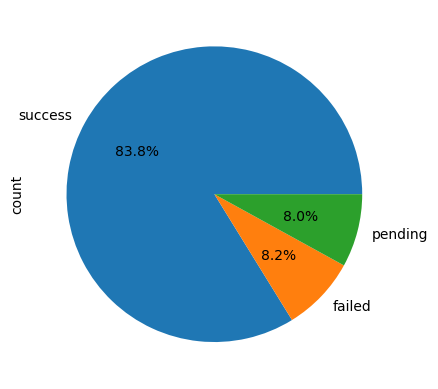

In [8]:
# Pie chart: Transaction status distribution
df['transaction_status'].value_counts().plot.pie(autopct='%1.1f%%')

<Axes: xlabel='region'>

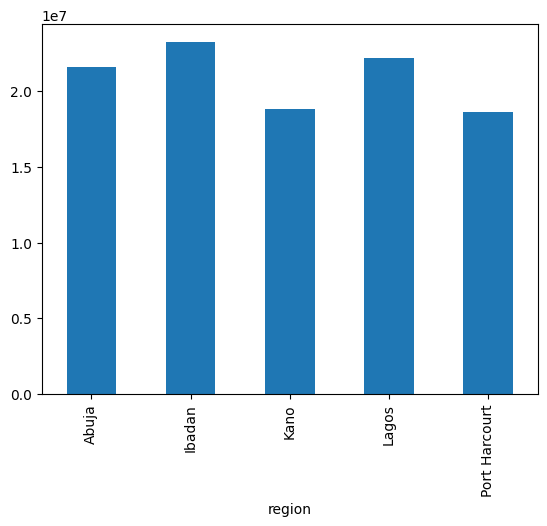

In [9]:
# Bar chart: Revenue by region
revenue_by_region = df[df['transaction_status']=='success'].groupby('region')['transaction_amount'].sum()
revenue_by_region.plot(kind='bar')

#Step 6: Insights (Analysis Summary)


In [ ]:
##Transaction Volume & Type: The platform handles a high volume of transfers and airtime purchases
# Airtime transactions appear frequently but often have smaller values compared to transfers

# Regional Performance: Lagos and Abuja are major hubs for both transaction count and high-value payments

# Failure Analysis: Failures occur across different channels. For example, USSD airtime purchases and bank transfer bill payments have seen failures in regions like Kano and Ibadan

# Fraud Patterns: Fraudulent transactions (flagged '1') are often high-value. For instance, a transfer in Abuja for 474,598 and a bill payment in Port Harcourt for 470,295 were both flagged
 # Fraud is not limited to one channel, appearing in USSD, wallet, and bank transfers

#Device Trends: Transactions are initiated across Android, iOS, and Web platforms


#Step 7: Actionable Recommendations

In [ ]:
# Reduce Failed Transactions: Investigate the USSD gateway stability in Ibadan and Kano, where multiple airtime and bill failures were noted

# Increase Revenue: Introduce loyalty rewards for 'transfer' and 'bill' payment types, as these often involve higher transaction amounts

# Fraud Mitigation: Implement real-time velocity checks and extra authentication for transactions exceeding 300,000, as many flagged fraudulent transactions fall into this high-value bracket

# Growth Opportunity: Port Harcourt shows high activity but also several pending and failed transactions
# improving local network integration could capture more successful revenue.
# UX Improvement: Standardize the 'pending' transaction flow to notify users via their device (iOS/Android) once a status updates to success or failure to reduce user anxiety
